Kaggle competation

Predicting Smartphone Addiction
Playground Series - Season 6 Episode 8

In [1]:
# competitions/playground-series-s6e8

In [2]:
# kaggle data loading the data from the compitaion
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
!kaggle competitions download -c playground-series-s6e8

In [ ]:
# unzip
!unzip playground-series-s6e8.zip

In [5]:
# importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [6]:
# data loading
train = pd.read_csv('/content/train.csv')
test = pd.read_csv('/content/test.csv')

In [7]:
# first five rows
train.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact,addicted_label
0,0,24.0,NaN,1.83,1.59,2.11,7.46,122.0,38.0,8.63,Male,Medium,No,1
1,1,19.0,5.97,1.08,NaN,3.03,8.22,76.0,19.0,NaN,Female,Medium,No,0
2,2,18.0,5.09,NaN,NaN,NaN,6.25,134.0,60.0,7.47,Female,Low,Yes,0
3,3,21.0,6.42,1.26,1.42,3.36,8.85,112.0,94.0,8.66,Other,Low,NaN,1
4,4,26.0,11.20,1.87,2.81,1.95,5.25,NaN,NaN,13.39,Female,Medium,No,1


In [8]:
test.head()

,id,age,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,gender,stress_level,academic_work_impact
0,691369,30.0,9.34,NaN,0.77,4.09,7.15,153.0,16.0,NaN,Other,Medium,Yes
1,691370,NaN,NaN,1.91,NaN,1.20,8.67,239.0,148.0,10.68,Female,High,No
2,691371,26.0,8.48,3.64,NaN,3.39,7.47,106.0,123.0,NaN,Male,NaN,No
3,691372,20.0,8.37,2.99,1.69,2.53,5.45,178.0,55.0,9.88,Male,High,Yes
4,691373,25.0,8.25,4.02,1.21,2.32,8.46,63.0,86.0,10.72,Male,Low,No


In [9]:
# info
print(train.info())
print(test.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [10]:
# shape
print(train.shape)
print(test.shape)

(691369, 14)
(296302, 13)


In [11]:
# null values
print(train.isnull().sum())
print(test.isnull().sum())

id                              0
age                         28929
daily_screen_time_hours     95854
social_media_hours         133995
gaming_hours               126821
work_study_hours            51518
sleep_hours                 44480
notifications_per_day       67584
app_opens_per_day           80710
weekend_screen_time        112063
gender                      29034
stress_level                55148
academic_work_impact        44224
addicted_label                  0
dtype: int64
id                             0
age                        17138
daily_screen_time_hours    32788
social_media_hours         47397
gaming_hours               59420
work_study_hours           27777
sleep_hours                22455
notifications_per_day      34221
app_opens_per_day          25705
weekend_screen_time        50697
gender                     14212
stress_level               19626
academic_work_impact       25721
dtype: int64


In [12]:
# cannot remove nulls

In [13]:
# duplicates
print(train.duplicated().sum())
print(test.duplicated().sum())

0
0


In [14]:
# describing
print(train.describe())
print(test.describe())

                  id            age  daily_screen_time_hours  \
count  691369.000000  662440.000000            595515.000000   
mean   345684.000000      26.615408                 7.640865   
std    199581.183466       5.153162                 2.721446   
min         0.000000      18.000000                 0.500000   
25%    172842.000000      22.000000                 5.480000   
50%    345684.000000      27.000000                 7.770000   
75%    518526.000000      31.000000                 9.840000   
max    691368.000000      35.000000                15.000000   

       social_media_hours   gaming_hours  work_study_hours    sleep_hours  \
count       557374.000000  564548.000000     639851.000000  646889.000000   
mean             2.471038       1.459265          2.366971       6.804334   
std              1.316137       0.934552          1.258797       1.234512   
min              0.000000       0.000000          0.000000       4.500000   
25%              1.450000       0.7000

In [15]:
# categorical columns
print(train.select_dtypes(include=['object']).columns)

Index(['gender', 'stress_level', 'academic_work_impact'], dtype='object')


In [16]:
cat_cols = ['gender', 'stress_level', 'academic_work_impact']

for i in cat_cols:
    print(train[i].value_counts())

gender
Male      223662
Female    221595
Other     217078
Name: count, dtype: int64
stress_level
High      220873
Low       207783
Medium    207565
Name: count, dtype: int64
academic_work_impact
Yes    330566
No     316579
Name: count, dtype: int64


Cleaning

In [17]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   id                       691369 non-null  int64  
 1   age                      662440 non-null  float64
 2   daily_screen_time_hours  595515 non-null  float64
 3   social_media_hours       557374 non-null  float64
 4   gaming_hours             564548 non-null  float64
 5   work_study_hours         639851 non-null  float64
 6   sleep_hours              646889 non-null  float64
 7   notifications_per_day    623785 non-null  float64
 8   app_opens_per_day        610659 non-null  float64
 9   weekend_screen_time      579306 non-null  float64
 10  gender                   662335 non-null  object 
 11  stress_level             636221 non-null  object 
 12  academic_work_impact     647145 non-null  object 
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [18]:
train.shape

(691369, 14)

In [19]:
df.columns

NameError: name 'df' is not defined

In [20]:
# handeling the missing values with imputer and column transformer
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

# Reload train data to ensure a clean state after previous corruption
train = pd.read_csv('/content/train.csv')

# Separate ID and target columns as they should not be imputed
id_col = train['id']
addicted_label_col = train['addicted_label']

# Drop 'id' and 'addicted_label' from the training data for imputation
train_features = train.drop(columns=['id', 'addicted_label'])

# Define imputers
mode_imputer = SimpleImputer(strategy='most_frequent')
median_imputer = SimpleImputer(strategy='median')
mean_imputer = SimpleImputer(strategy='mean')

# Define columns for each imputation strategy based on train.info() output and variable names
mean_cols = ['age', 'daily_screen_time_hours', 'gaming_hours', 'sleep_hours', 'work_study_hours']
median_cols = ['social_media_hours', 'notifications_per_day', 'app_opens_per_day']
mode_cols = ['gender', 'stress_level', 'academic_work_impact', 'weekend_screen_time']

# Create a list of all feature column names that will be transformed
all_imputed_features = mode_cols + median_cols + mean_cols

# Create a ColumnTransformer to apply different imputers to different columns
transformer = ColumnTransformer(transformers=[
    ('mode_imputer', mode_imputer, mode_cols),
    ('median_imputer', median_imputer, median_cols),
    ('mean_imputer', mean_imputer, mean_cols)
], remainder='passthrough') # 'passthrough' will keep other columns not specified, but we've already dropped 'id' and 'addicted_label'

# Apply the transformation to the feature set
train_transformed_array = transformer.fit_transform(train_features)

# Get the feature names after transformation, maintaining order for reconstruction
def get_feature_names(column_transformer):
    output_features = []
    for name, estimator, features in column_transformer.transformers_:
        if name != 'remainder' and estimator != 'drop':
            if hasattr(estimator, 'get_feature_names_out'):
                output_features.extend(estimator.get_feature_names_out(features))
            else:
                output_features.extend(features)
    return output_features


# Get the column names in the order they appear after transformation
transformed_columns = mode_cols + median_cols + mean_cols

# Reconstruct the DataFrame with the transformed features and original ID and target columns
train = pd.DataFrame(train_transformed_array, columns=transformed_columns)

# Convert columns to their appropriate types. The imputer output is float64 or object.
for col in mean_cols + median_cols:
    train[col] = train[col].astype(float)
for col in mode_cols:
    train[col] = train[col].astype(object)

# Add back the 'id' and 'addicted_label' columns
train['id'] = id_col.values
train['addicted_label'] = addicted_label_col.values

# Ensure 'id' and 'addicted_label' are int64
train['id'] = train['id'].astype('int64')
train['addicted_label'] = train['addicted_label'].astype('int64')

# Display info to verify dtypes
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   gender                   691369 non-null  object 
 1   stress_level             691369 non-null  object 
 2   academic_work_impact     691369 non-null  object 
 3   weekend_screen_time      691369 non-null  object 
 4   social_media_hours       691369 non-null  float64
 5   notifications_per_day    691369 non-null  float64
 6   app_opens_per_day        691369 non-null  float64
 7   age                      691369 non-null  float64
 8   daily_screen_time_hours  691369 non-null  float64
 9   gaming_hours             691369 non-null  float64
 10  sleep_hours              691369 non-null  float64
 11  work_study_hours         691369 non-null  float64
 12  id                       691369 non-null  int64  
 13  addicted_label           691369 non-null  int64  
dtypes: f

In [22]:
train

,gender,stress_level,academic_work_impact,weekend_screen_time,social_media_hours,notifications_per_day,app_opens_per_day,age,daily_screen_time_hours,gaming_hours,sleep_hours,work_study_hours,id,addicted_label
0,Male,Medium,No,8.63,1.83,122.0,38.0,24.000000,7.640865,1.590000,7.46,2.110000,0,1
1,Female,Medium,No,7.67,1.08,76.0,19.0,19.000000,5.970000,1.459265,8.22,3.030000,1,0
2,Female,Low,Yes,7.47,2.31,134.0,60.0,18.000000,5.090000,1.459265,6.25,2.366971,2,0
3,Other,Low,Yes,8.66,1.26,112.0,94.0,21.000000,6.420000,1.420000,8.85,3.360000,3,1
4,Female,Medium,No,13.39,1.87,150.0,104.0,26.000000,11.200000,2.810000,5.25,1.950000,4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,Male,High,No,12.89,3.25,86.0,94.0,22.000000,10.780000,1.570000,7.71,1.650000,691364,1
691365,Female,High,No,8.47,1.86,221.0,42.0,20.000000,3.450000,0.890000,6.59,0.300000,691365,1
691366,Other,Medium,No,7.79,2.31,150.0,86.0,26.615408,7.640865,1.459265,6.16,2.060000,691366,1
691367,Other,High,Yes,7.71,3.69,171.0,62.0,22.000000,11.780000,0.230000,5.53,1.350000,691367,1


In [21]:
train = pd.DataFrame(train, columns=df.columns)
train.sample(15)

NameError: name 'df' is not defined

In [23]:
# changing the type of age , notification per day , app open to discrete
train['age'] = train['age'].astype('int64')
train['notifications_per_day'] = train['notifications_per_day'].astype('int64')
train['app_opens_per_day'] = train['app_opens_per_day'].astype('int64')

In [24]:
train['weekend_screen_time'] = train['weekend_screen_time'].astype('float64')
train['addicted_label'] = train['addicted_label'].astype('object')

In [25]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   gender                   691369 non-null  object 
 1   stress_level             691369 non-null  object 
 2   academic_work_impact     691369 non-null  object 
 3   weekend_screen_time      691369 non-null  float64
 4   social_media_hours       691369 non-null  float64
 5   notifications_per_day    691369 non-null  int64  
 6   app_opens_per_day        691369 non-null  int64  
 7   age                      691369 non-null  int64  
 8   daily_screen_time_hours  691369 non-null  float64
 9   gaming_hours             691369 non-null  float64
 10  sleep_hours              691369 non-null  float64
 11  work_study_hours         691369 non-null  float64
 12  id                       691369 non-null  int64  
 13  addicted_label           691369 non-null  object 
dtypes: f

In [26]:
# now we can do analysis
numeric_cols = ['age', 'daily_screen_time_hours', 'gaming_hours', 'sleep_hours', 'work_study_hours', 'social_media_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time']
categorical_cols = ['gender', 'stress_level', 'academic_work_impact','addicted_label']
id = ['id']

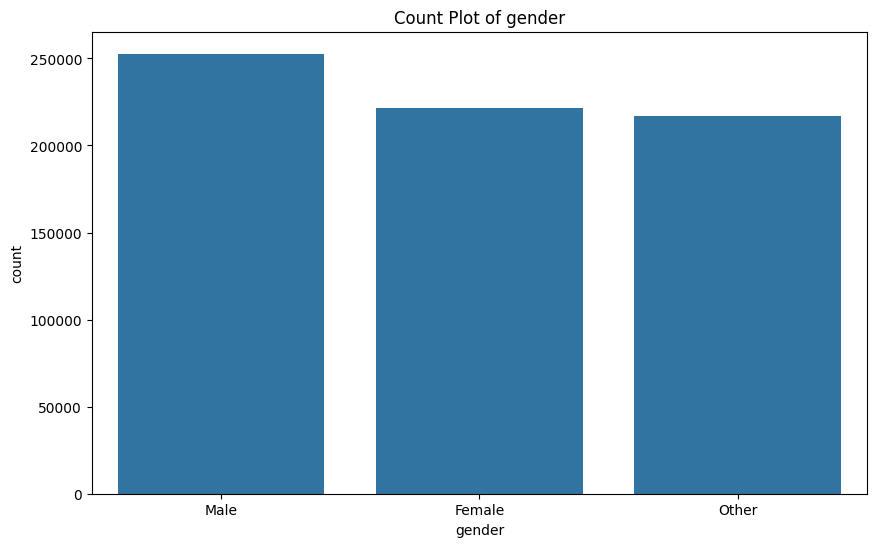

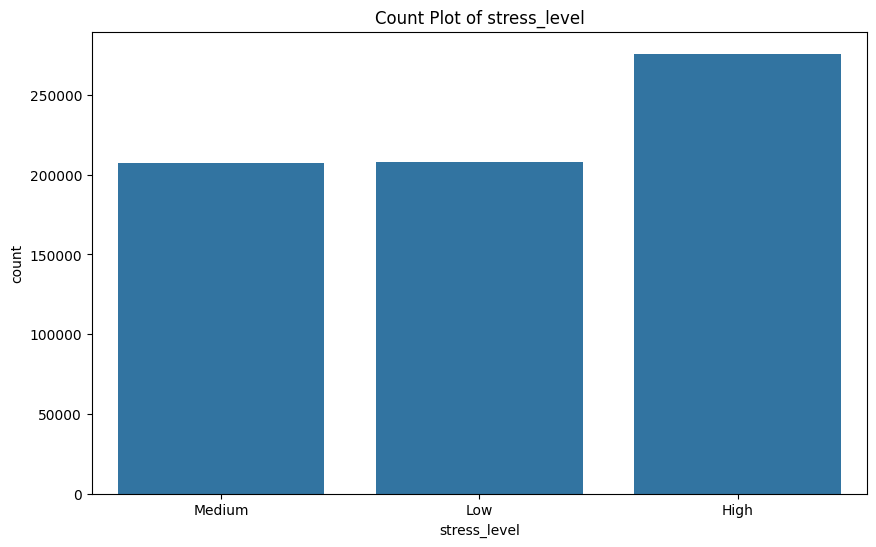

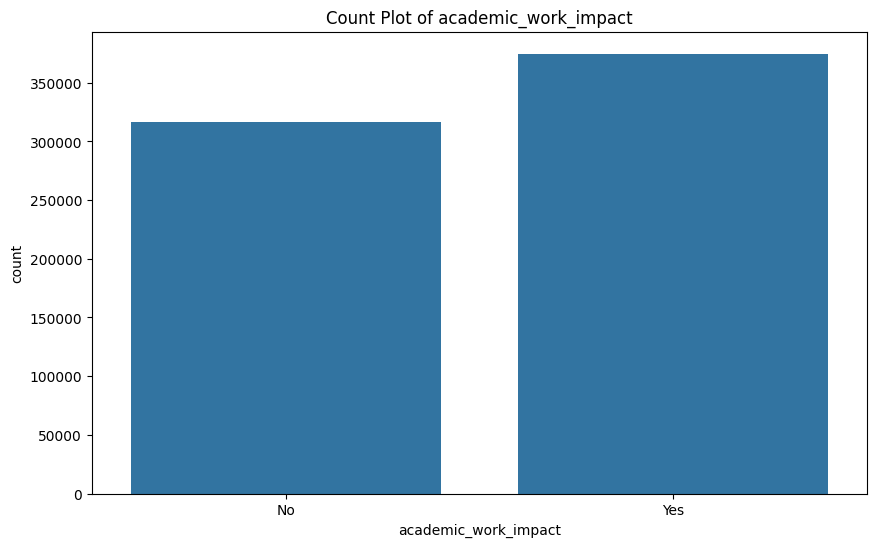

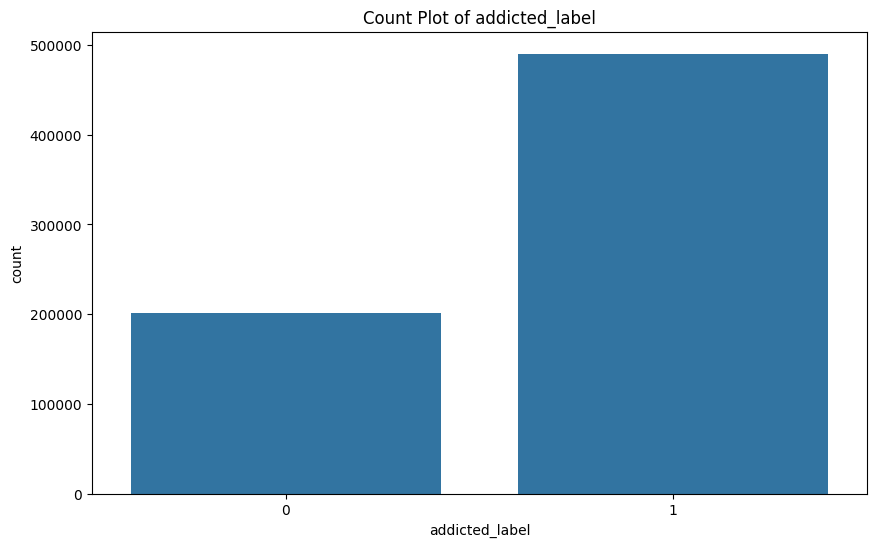

In [27]:
# count plot for each categorical columns
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=train, x=col)
    plt.title(f'Count Plot of {col}')
    plt.show()

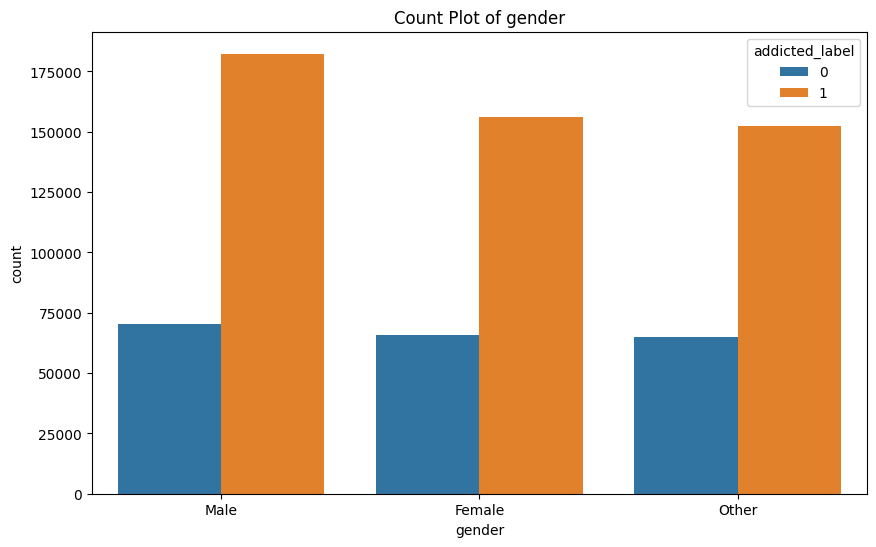

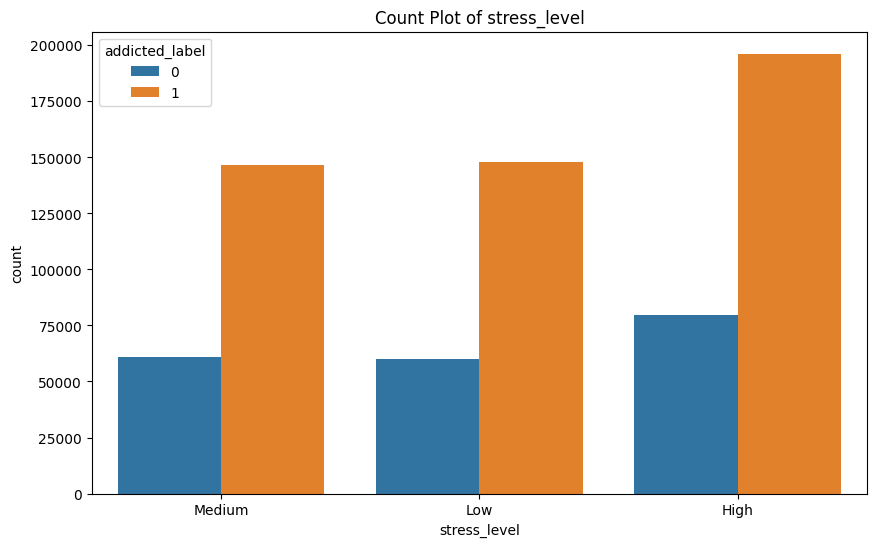

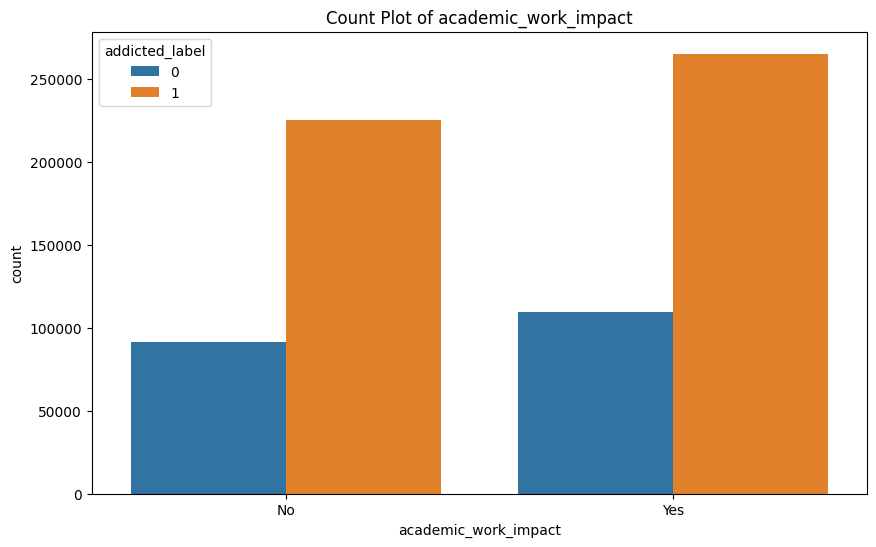

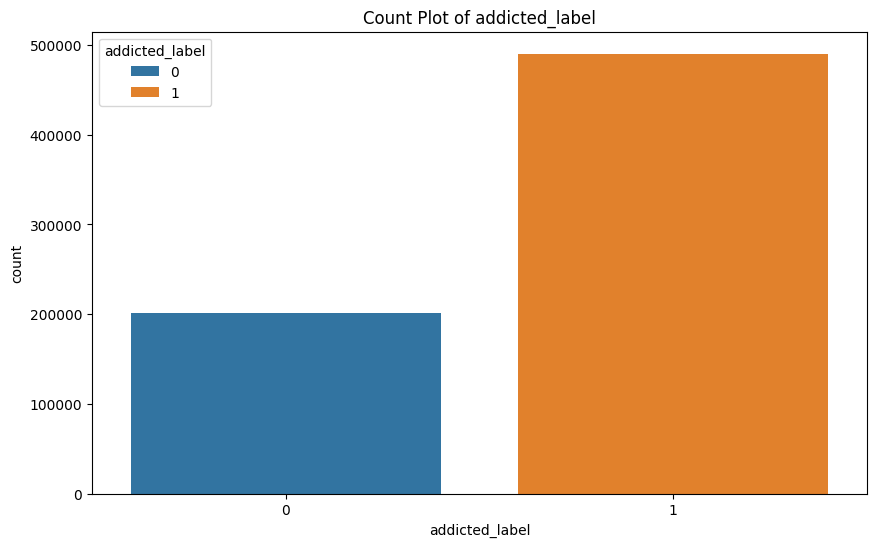

In [28]:
# count plot with addicited lable
for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(data=train, x=col, hue='addicted_label')
    plt.title(f'Count Plot of {col}')
    plt.show()

<Axes: >

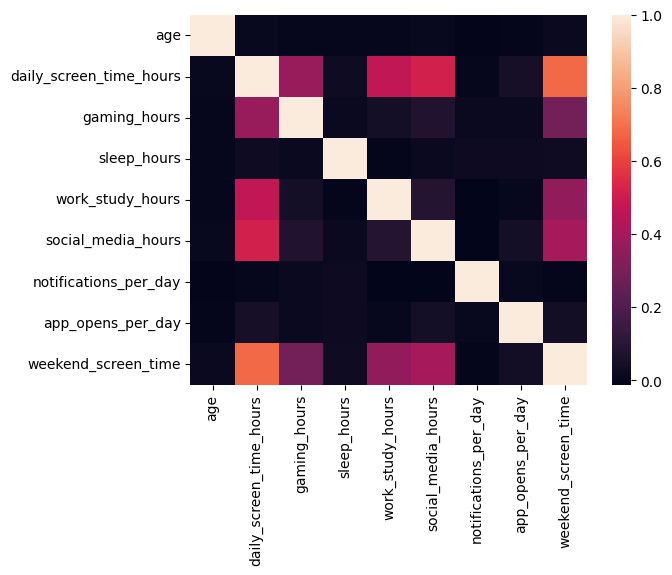

In [29]:
sns.heatmap(train[numeric_cols].corr())

In [30]:
# checking via vif
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif_data = pd.DataFrame()
vif_data["feature"] = numeric_cols
vif_data["VIF"] = [variance_inflation_factor(train[numeric_cols].values, i) for i in range(train[numeric_cols].shape[1])]
vif_data.sort_values(by='VIF', ascending=False)

,feature,VIF
1,daily_screen_time_hours,29.052811
8,weekend_screen_time,23.298715
3,sleep_hours,21.180574
0,age,19.232576
5,social_media_hours,7.822121
4,work_study_hours,6.729676
6,notifications_per_day,6.075072
7,app_opens_per_day,5.896347
2,gaming_hours,4.944500


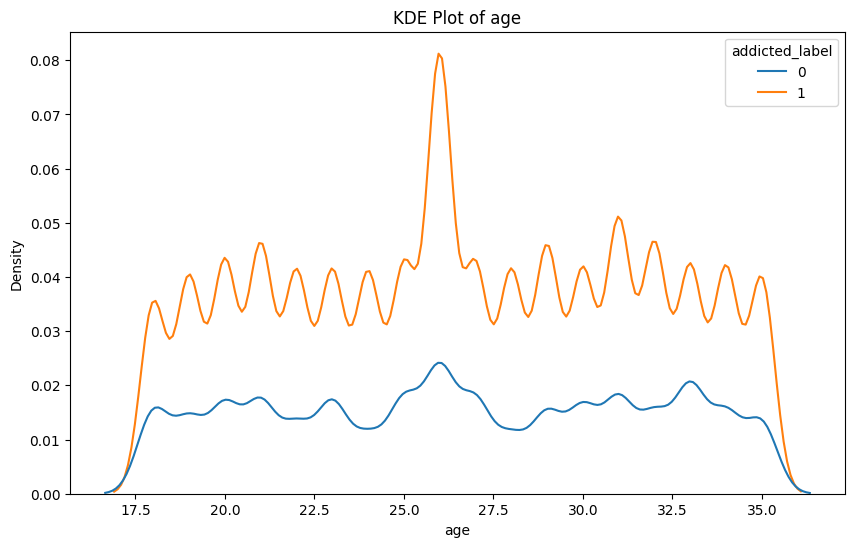

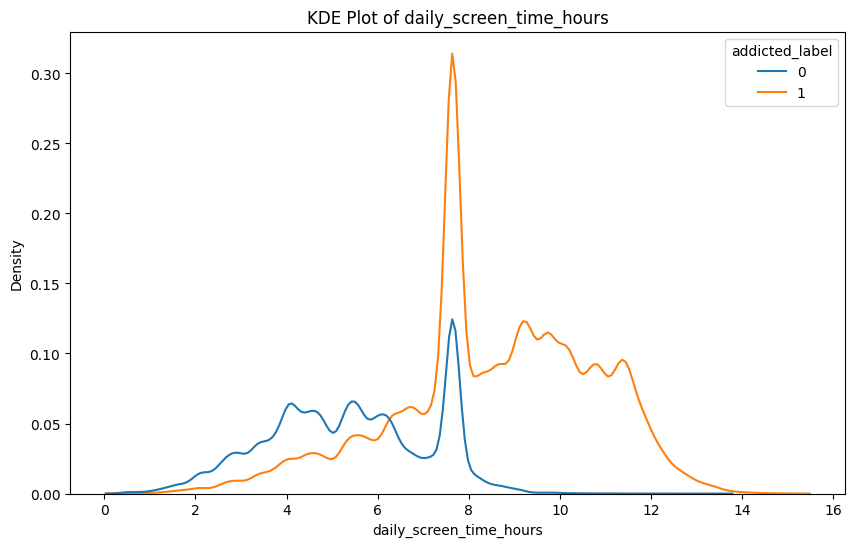

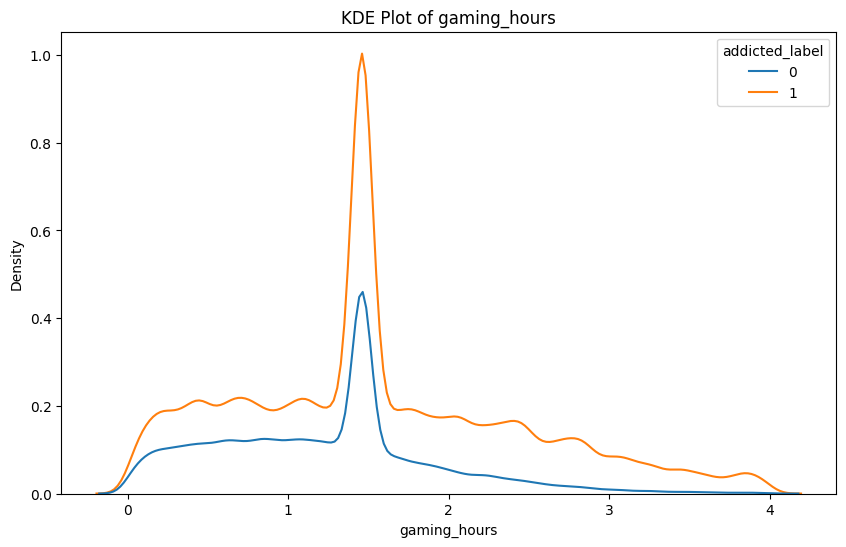

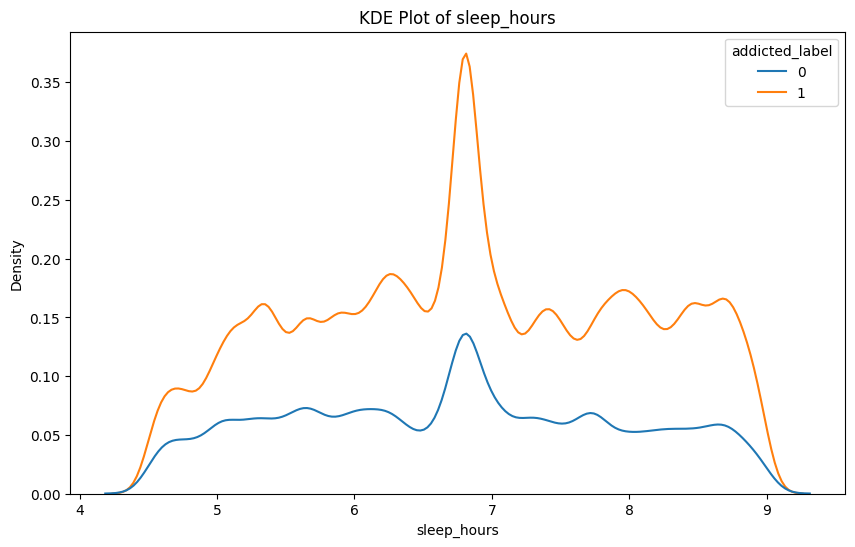

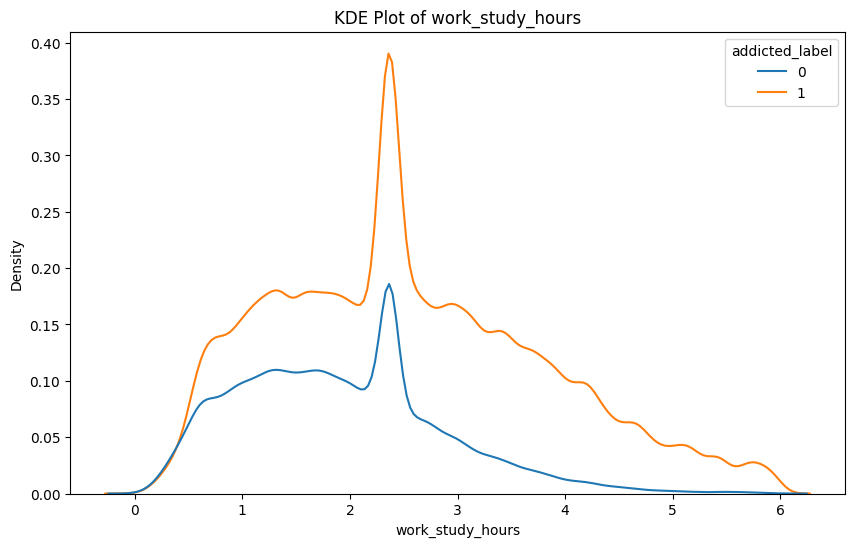

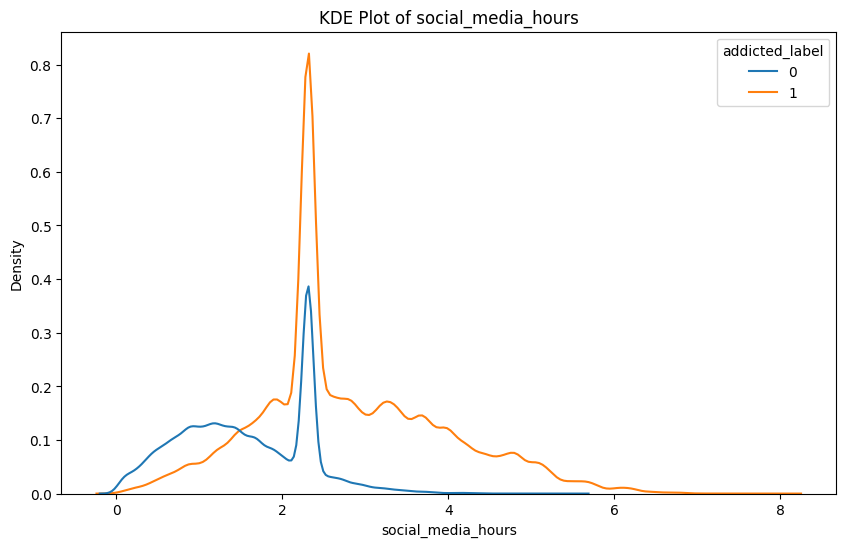

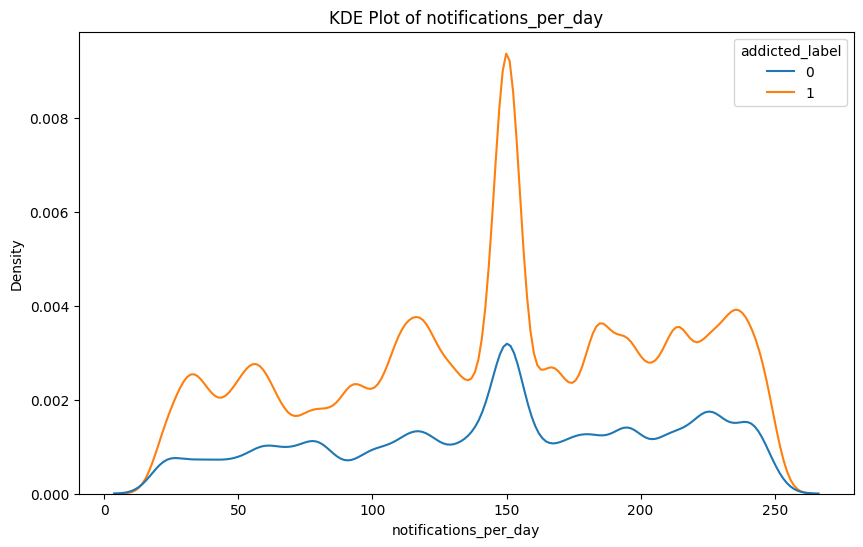

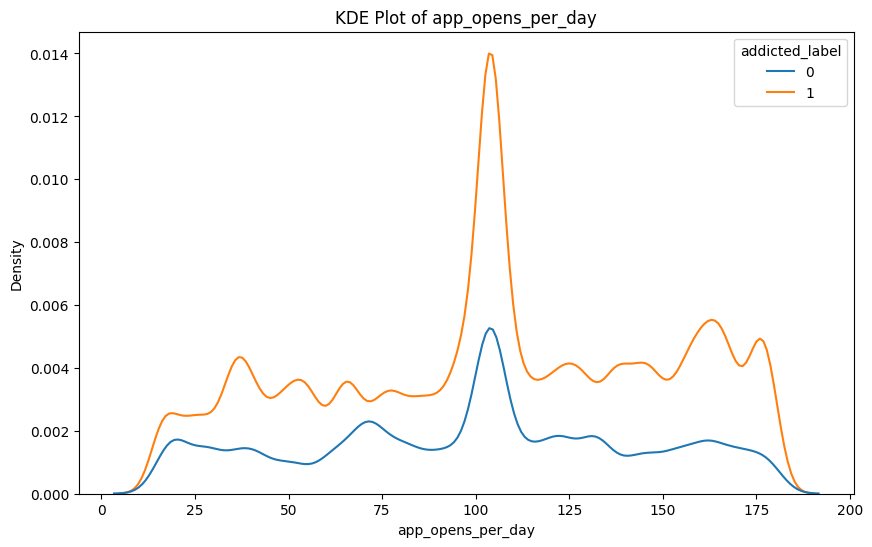

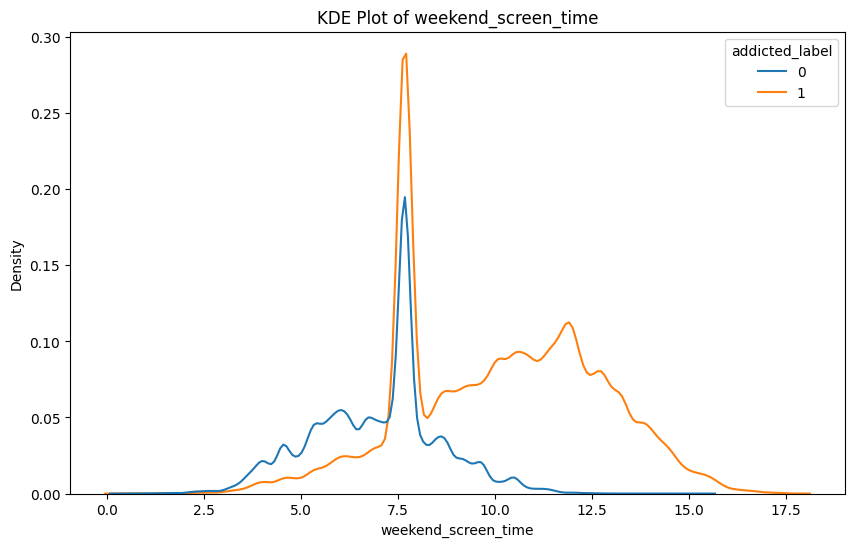

In [31]:
# kde of numeric colms
for col in numeric_cols:
    plt.figure(figsize=(10, 6))
    sns.kdeplot(data=train, x=col , hue='addicted_label')
    plt.title(f'KDE Plot of {col}')
    plt.show()

In [32]:
data = numeric_cols + cat_cols
data

['age',
 'daily_screen_time_hours',
 'gaming_hours',
 'sleep_hours',
 'work_study_hours',
 'social_media_hours',
 'notifications_per_day',
 'app_opens_per_day',
 'weekend_screen_time',
 'gender',
 'stress_level',
 'academic_work_impact']

In [33]:
# encoding and label encoding
from sklearn.preprocessing import LabelEncoder , OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import make_pipeline

ordinal_encoder = OrdinalEncoder()

categorical_features_to_encode = ['gender', 'stress_level', 'academic_work_impact']

preprocessor = ColumnTransformer(
    transformers=[
        ('cat_encoder', ordinal_encoder, categorical_features_to_encode)
    ],
    remainder='passthrough'
)

train_encoded_array = preprocessor.fit_transform(train[data])


encoded_column_names = [f'encoded_{col}' for col in categorical_features_to_encode]


remaining_numeric_cols = [col for col in data if col not in categorical_features_to_encode]

train_encoded = pd.DataFrame(train_encoded_array, columns=encoded_column_names + remaining_numeric_cols, index=train.index)

final_train = pd.concat([
    train['id'],
    train_encoded, # This now contains encoded categorical and original numeric features
    train['addicted_label']
], axis=1)

train = final_train

# Display info to verify dtypes and structure
print(train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 691369 entries, 0 to 691368
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   id                            691369 non-null  int64  
 1   encoded_gender                691369 non-null  float64
 2   encoded_stress_level          691369 non-null  float64
 3   encoded_academic_work_impact  691369 non-null  float64
 4   age                           691369 non-null  float64
 5   daily_screen_time_hours       691369 non-null  float64
 6   gaming_hours                  691369 non-null  float64
 7   sleep_hours                   691369 non-null  float64
 8   work_study_hours              691369 non-null  float64
 9   social_media_hours            691369 non-null  float64
 10  notifications_per_day         691369 non-null  float64
 11  app_opens_per_day             691369 non-null  float64
 12  weekend_screen_time           691369 non-nul

In [34]:
train

,id,encoded_gender,encoded_stress_level,encoded_academic_work_impact,age,daily_screen_time_hours,gaming_hours,sleep_hours,work_study_hours,social_media_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,addicted_label
0,0,1.0,2.0,0.0,24.0,7.640865,1.590000,7.46,2.110000,1.83,122.0,38.0,8.63,1
1,1,0.0,2.0,0.0,19.0,5.970000,1.459265,8.22,3.030000,1.08,76.0,19.0,7.67,0
2,2,0.0,1.0,1.0,18.0,5.090000,1.459265,6.25,2.366971,2.31,134.0,60.0,7.47,0
3,3,2.0,1.0,1.0,21.0,6.420000,1.420000,8.85,3.360000,1.26,112.0,94.0,8.66,1
4,4,0.0,2.0,0.0,26.0,11.200000,2.810000,5.25,1.950000,1.87,150.0,104.0,13.39,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
691364,691364,1.0,0.0,0.0,22.0,10.780000,1.570000,7.71,1.650000,3.25,86.0,94.0,12.89,1
691365,691365,0.0,0.0,0.0,20.0,3.450000,0.890000,6.59,0.300000,1.86,221.0,42.0,8.47,1
691366,691366,2.0,2.0,0.0,26.0,7.640865,1.459265,6.16,2.060000,2.31,150.0,86.0,7.79,1
691367,691367,2.0,0.0,1.0,22.0,11.780000,0.230000,5.53,1.350000,3.69,171.0,62.0,7.71,1


In [35]:
train.drop(columns=['id'],inplace=True)

In [36]:
# normalisaion and standarisation
from sklearn.preprocessing import MinMaxScaler , StandardScaler
standard_scaler = StandardScaler()
min_max_scaler = MinMaxScaler()

pipe = make_pipeline(standard_scaler)
train_num = pipe.fit(train[numeric_cols])

In [37]:
feat_names = train_num.feature_names_in_
trans_col = train_num.transform(train[numeric_cols])

In [38]:
train_trans = pd.DataFrame(trans_col, columns=feat_names, index=train.index)

In [39]:
train.columns
cat_cols = ['encoded_gender','encoded_stress_level','encoded_academic_work_impact']
train_trans = pd.concat([train_trans,train[cat_cols]],axis=1)

In [40]:
train_trans

,age,daily_screen_time_hours,gaming_hours,sleep_hours,work_study_hours,social_media_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,encoded_gender,encoded_stress_level,encoded_academic_work_impact
0,-0.513241,0.000000,1.548083e-01,0.549070,-0.212199,-0.515298,-0.387965,-1.433483,-0.206262,1.0,2.0,0.0
1,-1.504184,-0.661532,-5.258620e-16,1.185512,0.547511,-1.149041,-1.122500,-1.853821,-0.562074,0.0,2.0,0.0
2,-1.702372,-1.009943,-5.258620e-16,-0.464212,0.000000,-0.109703,-0.196347,-0.946776,-0.636201,0.0,1.0,1.0
3,-1.107806,-0.483367,-4.649477e-02,1.713088,0.820016,-0.996942,-0.547646,-0.194593,-0.195143,2.0,1.0,1.0
4,-0.116863,1.409138,1.599454e+00,-1.301636,-0.344323,-0.481498,0.059143,0.026638,1.557969,0.0,2.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
691364,-0.909618,1.242851,1.311256e-01,0.758426,-0.592055,0.684588,-0.962818,-0.194593,1.372651,1.0,0.0,0.0
691365,-1.305995,-1.659254,-6.740868e-01,-0.179488,-1.706847,-0.489948,1.192881,-1.344991,-0.265564,0.0,0.0,0.0
691366,-0.116863,0.000000,-5.258620e-16,-0.539580,-0.253488,-0.109703,0.059143,-0.371577,-0.517597,2.0,2.0,0.0
691367,-0.909618,1.638773,-1.455617e+00,-1.067157,-0.839786,1.056384,0.394474,-0.902530,-0.547248,2.0,0.0,1.0


In [41]:
# x and y break

In [42]:
X = train_trans
y = train['addicted_label']

In [43]:
# x train x test
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

In [44]:
X_train.shape , X_test.shape , y_test.shape , y_train.shape

((463217, 12), (228152, 12), (228152,), (463217,))

In [45]:
y_train.value_counts()

,count
addicted_label,
1,328625
0,134592


In [46]:
# model building
from sklearn.linear_model import LogisticRegression

# Convert y_train and y_test to integer type for classification
y_train = y_train.astype(int)
y_test = y_test.astype(int)

model1 = LogisticRegression(class_weight={1:0.2,0:0.6})
model1.fit(X_train,y_train)
y_pred = model1.predict(X_test)

0.8417563360467167
[[ 58655   7648]
 [ 32554 129295]]
              precision    recall  f1-score   support

           0       0.64      0.88      0.74     66303
           1       0.94      0.80      0.87    161849

    accuracy                           0.82    228152
   macro avg       0.79      0.84      0.81    228152
weighted avg       0.86      0.82      0.83    228152



Text(0.5, 1.0, 'ROC Curve')

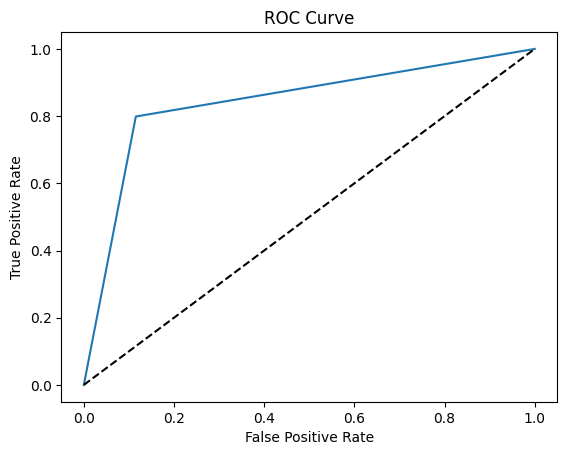

In [47]:
# eval
# ruc - auc graph
from sklearn.metrics import roc_auc_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

print(roc_auc_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

# plotting roc - auc
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

0.834589160866515
[[ 49520  16783]
 [ 12575 149274]]
              precision    recall  f1-score   support

           0       0.80      0.75      0.77     66303
           1       0.90      0.92      0.91    161849

    accuracy                           0.87    228152
   macro avg       0.85      0.83      0.84    228152
weighted avg       0.87      0.87      0.87    228152



Text(0.5, 1.0, 'ROC Curve')

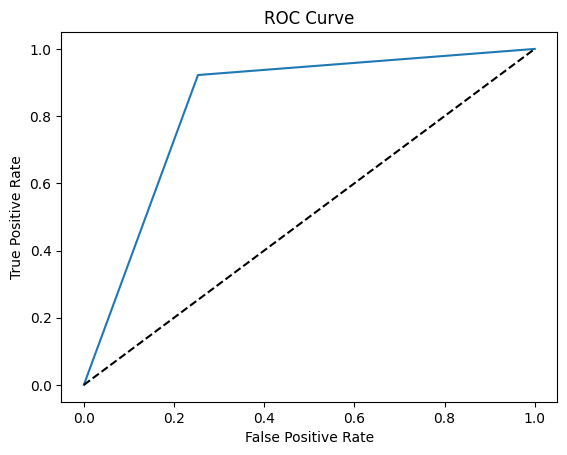

In [48]:
# model 2
from sklearn.ensemble import RandomForestClassifier
model2 = RandomForestClassifier(n_estimators=500,random_state=42)
model2.fit(X_train,y_train)
y_pred = model2.predict(X_test)

print(roc_auc_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

# plotting roc - auc
fpr, tpr, thresholds = roc_curve(y_test, y_pred)
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')

### Model 3: Gradient Boosting Classifier

Gradient Boosting Classifier Performance:
ROC AUC Score: 0.8481085891325677
Confusion Matrix:
 [[ 51815  14488]
 [ 13801 148048]]
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.78      0.79     66303
           1       0.91      0.91      0.91    161849

    accuracy                           0.88    228152
   macro avg       0.85      0.85      0.85    228152
weighted avg       0.88      0.88      0.88    228152



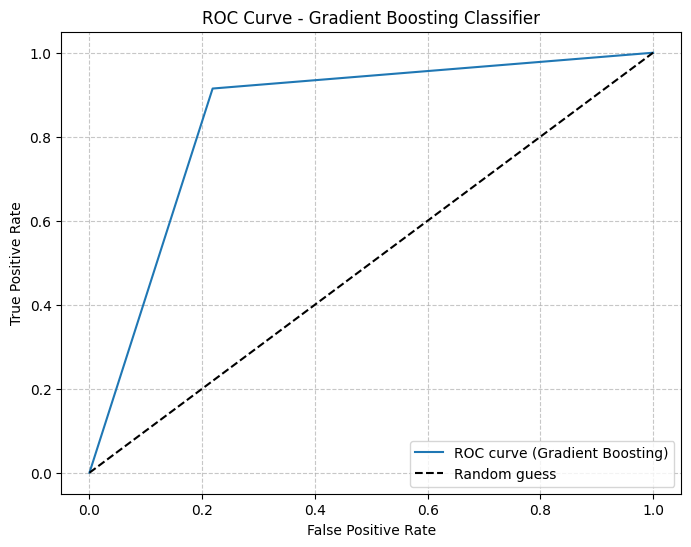

In [49]:
from sklearn.ensemble import GradientBoostingClassifier

model3 = GradientBoostingClassifier(n_estimators=500, random_state=42, learning_rate=0.05, max_depth=3)
model3.fit(X_train, y_train)
y_pred_gb = model3.predict(X_test)

print('Gradient Boosting Classifier Performance:')
print('ROC AUC Score:', roc_auc_score(y_test, y_pred_gb))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_gb))
print('Classification Report:\n', classification_report(y_test, y_pred_gb))

# Plotting ROC - AUC curve for Gradient Boosting
fpr_gb, tpr_gb, thresholds_gb = roc_curve(y_test, y_pred_gb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_gb, tpr_gb, label='ROC curve (Gradient Boosting)')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Gradient Boosting Classifier')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Model 4: XGBoost Classifier with Class Weighting for Imbalance

Scale Pos Weight: 0.40956104982883224


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [09:20:05] WARNING: /__w/xgboost/xgboost/src/learner.cc:793: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



XGBoost Classifier Performance:
ROC AUC Score: 0.8675013481620915
Confusion Matrix:
 [[ 60833   5470]
 [ 29537 132312]]
Classification Report:
               precision    recall  f1-score   support

           0       0.67      0.92      0.78     66303
           1       0.96      0.82      0.88    161849

    accuracy                           0.85    228152
   macro avg       0.82      0.87      0.83    228152
weighted avg       0.88      0.85      0.85    228152



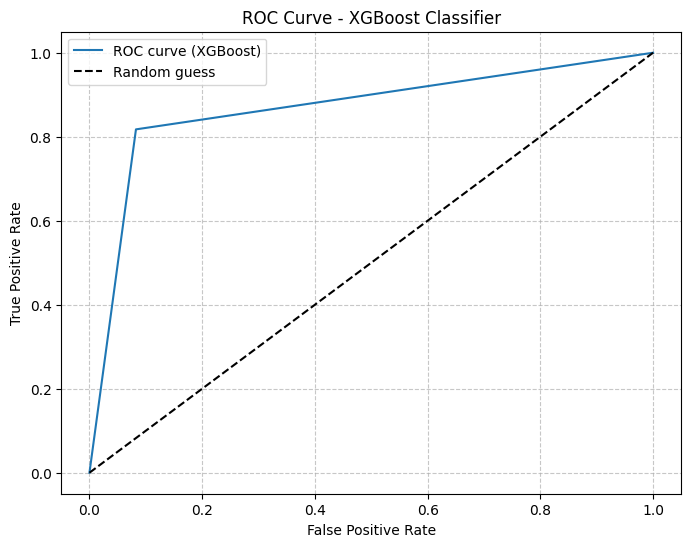

In [50]:
from xgboost import XGBClassifier

# Calculate the scale_pos_weight for handling class imbalance
# It is the ratio of the number of negative class to the positive class
neg_count = y_train.value_counts()[0]
pos_count = y_train.value_counts()[1]
scale_pos_weight_value = neg_count / pos_count

print(f"Scale Pos Weight: {scale_pos_weight_value}")

model4 = XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False, # Suppress warning
    n_estimators=500,
    random_state=42,
    learning_rate=0.05,
    max_depth=3,
    scale_pos_weight=scale_pos_weight_value # Address class imbalance
)

model4.fit(X_train, y_train)
y_pred_xgb = model4.predict(X_test)

print('\nXGBoost Classifier Performance:')
print('ROC AUC Score:', roc_auc_score(y_test, y_pred_xgb))
print('Confusion Matrix:\n', confusion_matrix(y_test, y_pred_xgb))
print('Classification Report:\n', classification_report(y_test, y_pred_xgb))

# Plotting ROC - AUC curve for XGBoost
fpr_xgb, tpr_xgb, thresholds_xgb = roc_curve(y_test, y_pred_xgb)
plt.figure(figsize=(8, 6))
plt.plot(fpr_xgb, tpr_xgb, label='ROC curve (XGBoost)')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost Classifier')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Comparing Classification Reports

In [51]:
from sklearn.metrics import classification_report
import pandas as pd

def parse_classification_report(y_true, y_pred, model_name):
    report = classification_report(y_true, y_pred, output_dict=True)
    df_report = pd.DataFrame(report).transpose()
    df_report = df_report.rename(columns=lambda x: f'{model_name}_{x}')
    return df_report

# Get predictions for each model
y_pred_lr = model1.predict(X_test)
y_pred_rf = model2.predict(X_test)
y_pred_gb = model3.predict(X_test)
y_pred_xgb = model4.predict(X_test)

# Parse reports for each model
report_lr = parse_classification_report(y_test, y_pred_lr, 'LogisticRegression')
report_rf = parse_classification_report(y_test, y_pred_rf, 'RandomForest')
report_gb = parse_classification_report(y_test, y_pred_gb, 'GradientBoosting')
report_xgb = parse_classification_report(y_test, y_pred_xgb, 'XGBoost')

# Combine reports into a single DataFrame
combined_reports = pd.concat([
    report_lr,
    report_rf,
    report_gb,
    report_xgb
], axis=1)

# Display the combined reports
display(combined_reports)

,LogisticRegression_precision,LogisticRegression_recall,LogisticRegression_f1-score,LogisticRegression_support,RandomForest_precision,RandomForest_recall,RandomForest_f1-score,RandomForest_support,GradientBoosting_precision,GradientBoosting_recall,GradientBoosting_f1-score,GradientBoosting_support,XGBoost_precision,XGBoost_recall,XGBoost_f1-score,XGBoost_support
0,0.643083,0.884651,0.744769,66303.000000,0.797488,0.746874,0.771352,66303.000000,0.789670,0.781488,0.785558,66303.000000,0.673155,0.917500,0.776560,66303.000000
1,0.944152,0.798862,0.865452,161849.000000,0.898932,0.922304,0.910468,161849.000000,0.910863,0.914729,0.912792,161849.000000,0.960300,0.817503,0.883166,161849.000000
accuracy,0.823793,0.823793,0.823793,0.823793,0.871323,0.871323,0.871323,0.871323,0.876008,0.876008,0.876008,0.876008,0.846563,0.846563,0.846563,0.846563
macro avg,0.793618,0.841756,0.805110,228152.000000,0.848210,0.834589,0.840910,228152.000000,0.850267,0.848109,0.849175,228152.000000,0.816727,0.867501,0.829863,228152.000000
weighted avg,0.856659,0.823793,0.830380,228152.000000,0.869452,0.871323,0.870040,228152.000000,0.875643,0.876008,0.875817,228152.000000,0.876853,0.846563,0.852186,228152.000000


In [3]:
print('hek')

hek
